# Uncertainty-Aware Traffic Routing Using Search-Based Algorithms

---

## Problem Statement

Traditional route-planning systems typically compute a single shortest path assuming fixed and deterministic travel times. However, real-world traffic conditions are inherently uncertain due to congestion and incidents. Ignoring this uncertainty can lead to routes that are optimal on average but unreliable in practice. The goal of this project is to design and implement an AI-based traffic routing system that incorporates search algorithms and uncertainty modeling to compute routes that are efficient and reliable.

> **Note:** AI assistance was used in generating code comments and documentation throughout this project.

## Phase 1: Dataset Construction

### Overview

The dataset was manually constructed to represent a real world road network across New York State. It is structured as a **graph**, where cities are nodes and roads connecting them are edges. The data is split into two CSV files.

---

### File 1: `ny_graph_nodes.csv` -> Cities (Nodes)

This file contains **27 cities** across New York State, each representing a node in the traffic graph.

| Column | Description |
|---|---|
| `city` | Name of the city |
| `population` | Population of the city |
| `region` | Geographic region (e.g., NYC Metro, Western NY) |
| `lat` | Latitude coordinate |
| `lng` | Longitude coordinate |

---

### File 2: `ny_graph_edges.csv` —> Roads (Edges)

This file contains **41 road connections** between cities, each representing an edge in the traffic graph.

| Column | Description |
|---|---|
| `from_city` | Origin city |
| `to_city` | Destination city |
| `highway` | Highway/road name (e.g., I-90, I-87) |
| `miles` | Distance in miles |
| `speed_mph` | Speed limit in mph |
| `road_type` | Type of road (`interstate`, `state route`, `parkway`) |
| `am_peak_mean` | Average congestion multiplier during AM peak hours |
| `am_peak_std` | Standard deviation of AM peak congestion |
| `off_peak_mean` | Average congestion multiplier during off-peak hours |
| `off_peak_std` | Standard deviation of off-peak congestion |
| `pm_peak_mean` | Average congestion multiplier during PM peak hours |
| `pm_peak_std` | Standard deviation of PM peak congestion |
| `free_flow_time_min` | Travel time in minutes under free-flow (no traffic) conditions |

---

### Uncertainty Modeling

Each edge includes **congestion multipliers** with a mean and standard deviation for three time periods:

- **AM Peak** (morning rush hour) —> highest uncertainty in urban areas
- **Off Peak** (midday / night) —> lowest congestion and uncertainty
- **PM Peak** (evening rush hour) —> highest congestion overall

The congestion multiplier is applied to `free_flow_time_min` to simulate realistic travel times.

---

In [12]:
# Phase 1 - Data Structures and Graph Construction

import math
import random
from dataclasses import dataclass
from typing import List, Dict, Optional

@dataclass
class TrafficDistribution:
    """
    Represents the uncertainty in travel time for a given time period. Uses a mean and standard deviation (Gaussian model) as the traffic multiplier.
    
    Atttributes:
        mean (float): The average traffic multiplier
        std (float): The standard deviation of the traffic multiplier, representing uncertainty.
    """
    __slots__ = ['mean', 'std']
    mean: float
    std: float

    def sample(self) -> float:
        """
        Sample a traffic multiplier using a Gaussian distribution.
        
        :return: A traffic multiplier sampled from the distribution, ensuring it's at least 1.0 since traffic cannot be faster than free-flow speed.
        """
        return max(1.0, random.gauss(self.mean, self.std))

    def __repr__(self):
        """
        String representation of the traffic distribution for debugging.
        
        :return: A string showing the mean and standard deviation of the traffic distribution.
        """
        return f"TrafficDistribution(mean={self.mean}, std={self.std})"

@dataclass
class Edge:
    """
    Represents a road (edge) connecting two cities in the traffic graph.
    
    Attributes:
        from_city (str): The starting city of the road.
        to_city (str): The destination city of the road.
        highway (str): The name or number of the highway.
        miles (float): The length of the road in miles.
        speed_mph (float): The free flow speed in miles per hour.
        road_type (str): The type of road (e.g., 'interstate', 'state route').
        am_peak (TrafficDistribution): Traffic profile for morning rush hour.
        off_peak (TrafficDistribution): Traffic profile for midday/night.
        pm_peak (TrafficDistribution): Traffic profile for evening rush hour.
        free_flow_time_min (float): The travel time in minutes under free flow conditions, calculated as (miles / speed_mph) * 60.
    """
    __slots__ = ['from_city', 'to_city', 'highway', 'miles', 'speed_mph', 'road_type', 'am_peak', 'off_peak', 'pm_peak', 'free_flow_time_min']
    from_city: str
    to_city: str
    highway: str
    miles: float
    speed_mph: float
    road_type: str
    am_peak: TrafficDistribution
    off_peak: TrafficDistribution
    pm_peak: TrafficDistribution
    free_flow_time_min: float

    def get_travel_time(self, time_period: str, sampled: bool = False) -> float:
        """
        Returns travel time in minutes for a given time period.

        :param time_period: One of 'am_peak', 'off_peak', 'pm_peak'
        :param sampled: If True, sample from the traffic distribution; otherwise, use the mean multiplier.
        :return: Travel time in minutes, rounded to 2 decimal places.
        """
        distributions = {
            'am_peak': self.am_peak,
            'off_peak': self.off_peak,
            'pm_peak': self.pm_peak
        }

        if time_period not in distributions:
            raise ValueError(f"Invalid time_period '{time_period}'. Choose from: {list(distributions.keys())}")

        profile = distributions[time_period]

        if sampled:
            multiplier = profile.sample()
        else:
            multiplier = profile.mean

        return round(self.free_flow_time_min * multiplier, 2)

    def get_expected_travel_time_with_probabilistic_traffic(self, time_period: str) -> float:
        """
        Returns the sampled (uncertain) travel time in minutes for the given time period, drawn from the traffic distribution using a Gaussian model.

        :return: The sampled travel time in minutes, calculated using a randomly drawn traffic multiplier.
        """
        return self.get_travel_time(time_period, sampled=True)

    def get_expected_travel_time_with_traffic(self, time_period: str) -> float:
        """
        Returns the deterministic (mean) travel time in minutes for the given time period, using the average traffic multiplier with no randomness.
        
        Returns:
            The expected travel time in minutes, calculated using the mean traffic multiplier.
        """
        return self.get_travel_time(time_period, sampled=False)

    def get_travel_time_without_traffic(self) -> float:
        """
        Returns the free flow travel time in minutes, assuming zero traffic.
        
        :return: The free flow travel time in minutes with no traffic applied.
        """
        return self.free_flow_time_min

    def __lt__(self, other: 'Edge') -> bool:
        """
        Defines a deterministic ordering for edges so they can be compared in heaps.

        :param other: Another Edge to compare against.
        :return: True if this edge should sort before the other edge.
        """
        return (
            self.from_city,
            self.to_city,
            self.highway,
            self.free_flow_time_min,
            self.miles,
            self.speed_mph,
            self.road_type,
        ) < (
            other.from_city,
            other.to_city,
            other.highway,
            other.free_flow_time_min,
            other.miles,
            other.speed_mph,
            other.road_type,
        )

    def __repr__(self):
        return f"Edge({self.from_city} → {self.to_city} via {self.highway}, {self.miles} mi)"

@dataclass
class Node:
    """
    Represents a city (node) in the traffic graph.

    Attributes:
        city (str): The name of the city.
        population (int): The population of the city.
        region (str): The region of New York the city is located in.
            The cities are grouped into 5 regions:
                - NYC Metro — New York City, Bronx, Yonkers, Long Island City, etc.
                - Western NY — Buffalo, Rochester, Niagara Falls
                - Central NY — Syracuse, Utica, Rome
                - Capital Region — Albany, Schenectady, Troy, Saratoga Springs
                - Southern Tier — Binghamton
        lat (float): The latitude of the city, used for distance calculations.
        lng (float): The longitude of the city, used for distance calculations. 
    """
    __slots__ = ['city', 'population', 'region', 'lat', 'lng']
    city: str
    population: int
    region: str
    lat: float
    lng: float

    def haversine_distance(self, other: 'Node') -> float:
        """
        Computes straight line distance in miles to another node accounting for the earth's curvature.
        
        Useful as a heuristic for A* search. Why?
            - The Haversine distance gives us a lower bound on the actual travel distance between two cities, since roads cannot be perfectly straight and may have to navigate around terrain, infrastructure, etc.
            - This makes it an admissible heuristic for A* search, ensuring that it never overestimates the true cost to reach the goal, which is crucial for guaranteeing optimality of the A* algorithm.

        :param other: Another Node to which the distance is calculated.
        :return: The straight line distance in miles, rounded to 2 decimal places.
        """
        R = 3958.8 # This is the radius of the Earth in miles
        lat1, lat2 = math.radians(self.lat), math.radians(other.lat)
        dlat = math.radians(other.lat - self.lat)
        dlng = math.radians(other.lng - self.lng)
        a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlng / 2)**2
        return round(2 * R * math.asin(math.sqrt(a)), 2)

    def __repr__(self):
        """
        String representation of the Node for debugging.
        
        :return: A string showing the city name, region, and population of the node.
        """
        return f"Node({self.city}, region={self.region}, pop={self.population:,})"

@dataclass
class TrafficGraph:
    """
    Represents the full NY road network as an adjacency list graph. Nodes are cities, edges are roads with uncertainty-aware travel times.

    Attributes:
        nodes: A dictionary mapping city names to Node objects.
        edges: A list of all Edge objects in the graph.
        adjacency: A dictionary mapping city names to a list of outgoing Edge objects for efficient neighbor lookups.
    """
    __slots__ = ['nodes', 'edges', 'adjacency']
    nodes: Dict[str, Node]
    edges: List[Edge]
    adjacency: Dict[str, List[Edge]]

    def __init__(self):
        self.nodes: Dict[str, Node] = {}
        self.edges: List[Edge] = []
        self.adjacency: Dict[str, List[Edge]] = {}

    def load_nodes(self, filepath: str):
        """
        Load nodes from ny_graph_nodes.csv

        :param filepath: The path to the CSV file containing node data.
        :return: None
        """
        with open(filepath, 'r') as f:
            lines = f.read().splitlines()

        for line in lines[1:]:
            city, population, region, lat, lng = line.split(',')
            node = Node(
                city=city,
                population=int(population),
                region=region,
                lat=float(lat),
                lng=float(lng)
            )
            
            self.nodes[node.city] = node
            self.adjacency[node.city] = []

        print(f"Loaded {len(self.nodes)} nodes.")

    def load_edges(self, filepath: str):
        """
        Load edges from ny_graph_edges.csv

        :param filepath: The path to the CSV file containing edge data.
        :return: None
        """
        with open(filepath, 'r') as f:
            lines = f.read().splitlines()

        for line in lines[1:]:
            from_city, to_city, highway, miles, speed_mph, road_type, am_peak_mean, am_peak_std, off_peak_mean, off_peak_std, pm_peak_mean, pm_peak_std, free_flow_time_min = line.split(',')
            
            forward_edge = Edge(
                from_city=from_city,
                to_city=to_city,
                highway=highway,
                miles=float(miles),
                speed_mph=float(speed_mph),
                road_type=road_type,
                am_peak=TrafficDistribution(float(am_peak_mean), float(am_peak_std)),
                off_peak=TrafficDistribution(float(off_peak_mean), float(off_peak_std)),
                pm_peak=TrafficDistribution(float(pm_peak_mean), float(pm_peak_std)),
                free_flow_time_min=float(free_flow_time_min)
            )

            reverse_edge = Edge(
                from_city=to_city,
                to_city=from_city,
                highway=highway,
                miles=float(miles),
                speed_mph=float(speed_mph),
                road_type=road_type,
                am_peak=TrafficDistribution(float(am_peak_mean), float(am_peak_std)),
                off_peak=TrafficDistribution(float(off_peak_mean), float(off_peak_std)),
                pm_peak=TrafficDistribution(float(pm_peak_mean), float(pm_peak_std)),
                free_flow_time_min=float(free_flow_time_min)
            )

            self.edges.append(forward_edge)
            self.edges.append(reverse_edge)

            if forward_edge.from_city in self.adjacency:
                self.adjacency[forward_edge.from_city].append(forward_edge)
            if reverse_edge.from_city in self.adjacency:
                self.adjacency[reverse_edge.from_city].append(reverse_edge)

        print(f"Loaded {len(self.edges)} edges.")

    def get_node(self, city: str) -> Optional[Node]:
        """
        Get a node by city name.

        :param city: The name of the city to retrieve.
        :return: The Node object corresponding to the city, or None if not found.
        """
        return self.nodes.get(city)

    def get_neighbors(self, city: str) -> List[Edge]:
        """
        Get all edges from a given city.

        :param city: The name of the city to retrieve neighbors for.
        :return: A list of Edge objects representing the neighbors.
        """
        return self.adjacency.get(city, [])

    def get_edges_between(self, city_a: str, city_b: str) -> List[Edge]:
        """
        Get all road options between two cities.

        :param city_a: The name of the first city.
        :param city_b: The name of the second city.
        :return: A list of Edge objects representing the roads between the cities.
        """
        edges_between = []

        for edge in self.adjacency.get(city_a, []):
            if edge.to_city == city_b or edge.from_city == city_b:
                edges_between.append(edge)

        return edges_between

    def __repr__(self):
        """
        String representation of the TrafficGraph for debugging.
        
        :return: A string showing the number of nodes and edges in the graph.
        """
        return f"TrafficGraph(nodes={len(self.nodes)}, edges={len(self.edges)})"

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph: TrafficGraph, path=None, time_period: str = 'off_peak'):
    """
    Visualize the traffic graph using real GPS coordinates as node positions.

    Nodes are positioned by longitude/latitude so the map reflects the actual
    geography of New York State. Edge labels show the highway name and the
    expected (mean) travel time for the selected time period.

    :param graph: A loaded TrafficGraph instance.
    :param path: Optional list of city-name strings representing a route to
                 highlight in red.
    :param time_period: One of 'am_peak', 'off_peak', or 'pm_peak'. Controls
                        which traffic distribution is used to compute displayed
                        travel times. Defaults to 'off_peak'.
    """
    G = nx.Graph()

    # ── Add every city as a node ───────────────────────────────────────────────
    for city, node in graph.nodes.items():
        G.add_node(city, region=node.region, population=node.population)

    # ── Collapse forward/reverse duplicates so each road is drawn once ─────────
    seen_edges = set()
    for edge in graph.edges:
        edge_key = tuple(sorted((edge.from_city, edge.to_city)))
        if edge_key in seen_edges:
            continue
        seen_edges.add(edge_key)
        G.add_edge(
            edge.from_city,
            edge.to_city,
            highway=edge.highway,
            miles=edge.miles,
            travel_time=edge.get_expected_travel_time_with_traffic(time_period)
        )

    # ── Use real GPS coordinates for positions (lng → x, lat → y) ─────────────
    pos = {city: (node.lng, node.lat) for city, node in graph.nodes.items()}

    plt.figure(figsize=(14, 10))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=900,
        font_size=8,
        font_weight='bold',
        edge_color='gray'
    )

    # ── Edge labels: highway name + expected travel time ──────────────────────
    edge_labels = {
        (u, v): f"{data['highway']}\n{data['travel_time']:.1f} min"
        for u, v, data in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # ── Highlight path in red if provided ─────────────────────────────────────
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2.5)

    plt.title(f"Traffic Graph Visualization ({time_period.replace('_', ' ').title()})")
    plt.axis('off')
    plt.show()

Loaded 28 nodes.
Loaded 84 edges.


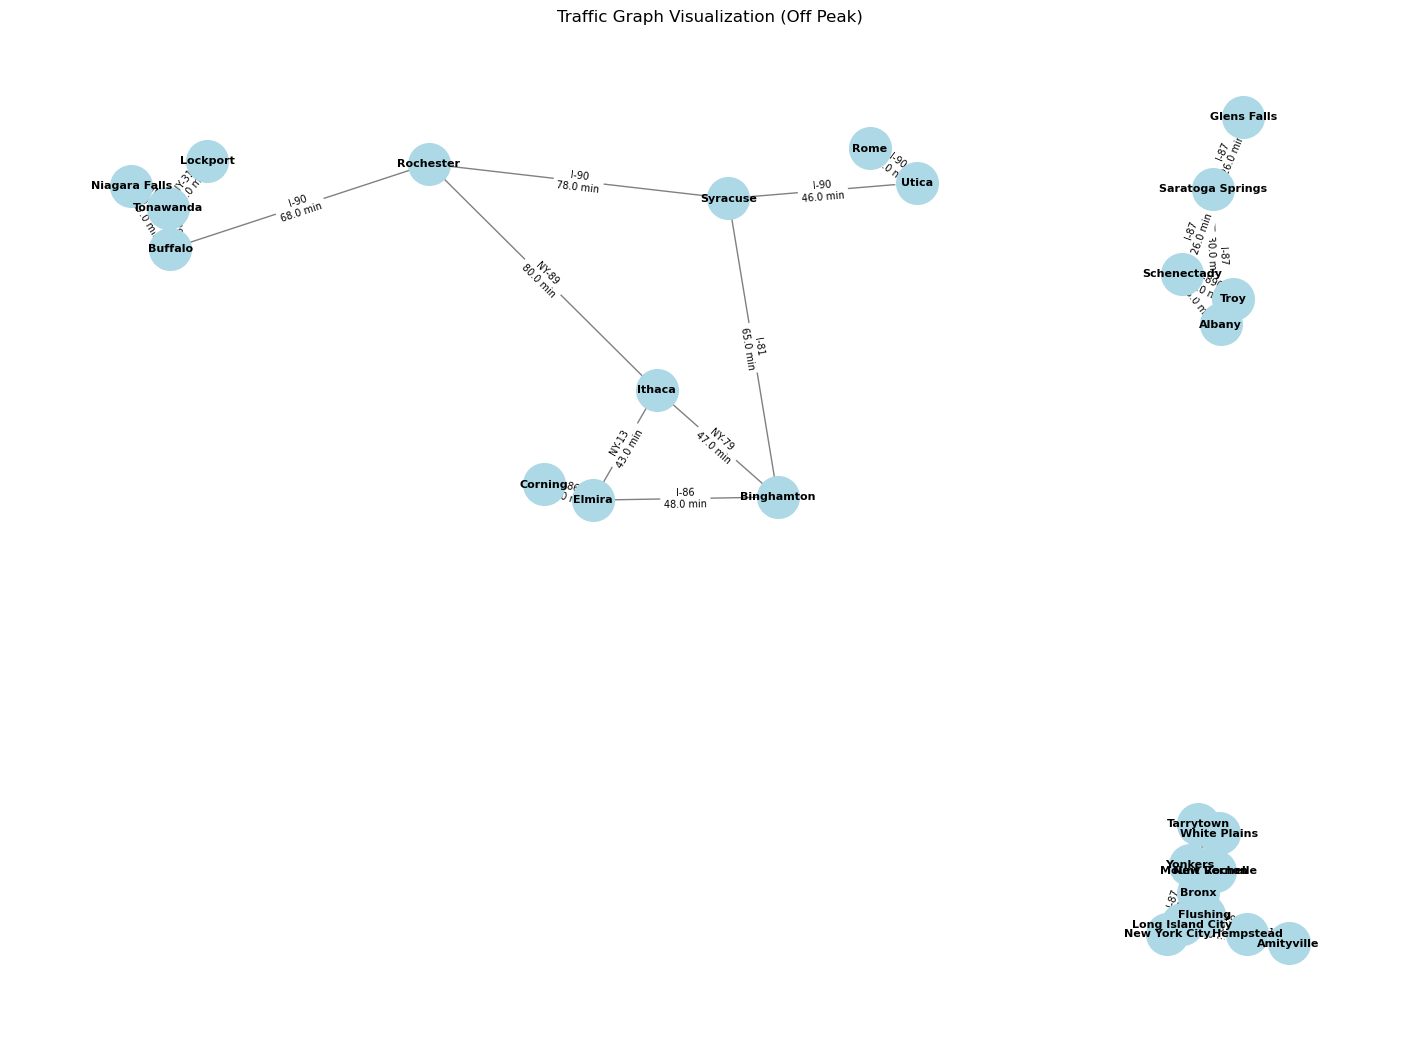

In [14]:
traffic_graph = TrafficGraph()
traffic_graph.load_nodes('data/CSCI 630 - Artificial Intelligence - Project Data - ny_graph_nodes.csv')
traffic_graph.load_edges('data/CSCI 630 - Artificial Intelligence - Project Data - ny_graph_edges.csv')

# Visualize the full graph using off-peak traffic conditions.
# Change time_period to 'am_peak' or 'pm_peak' to see rush-hour travel times.
visualize_graph(traffic_graph, time_period='off_peak')

## Phase 2: Basic Algorithms

In this phase, we implemented the baseline search algorithms for route finding on the traffic graph.

### Uniform Cost Search

Uniform Cost Search (UCS) was implemented to find the least-cost path between a start city and a goal city using only the free-flow travel time on each edge. This version does not consider traffic patterns, time-of-day effects, or probabilistic behavior. It serves as a deterministic shortest-path algorithm for the base road network.

### A* Search

A* Search was implemented as an informed version of shortest-path search. Like UCS, it uses free-flow travel time only and does not include traffic, time-based cost changes, or probability distributions. The heuristic helps guide the search toward the goal more efficiently while still aiming to return the optimal path under these simplified conditions.


In [15]:
import heapq

def uniform_cost_search(graph: TrafficGraph, start: str, goal: str):
    """
    Implements Uniform Cost Search to find the least costly path from start to goal based on expected travel time without traffic.

    :param graph: The TrafficGraph to search within.
    :param start: The starting city name.
    :param goal: The destination city name.
    :return: A tuple of (path, nodes_expanded), where path is a list of Edge objects or None.
    """
    # Priority queue for UCS
    frontier = []

    if not graph.get_node(start) or not graph.get_node(goal):
        return None, 0
    
    heapq.heappush(frontier, (0, start, [])) # (cumulative_cost, current_city, path_taken)
    
    explored = set()
    nodes_expanded = 0

    while frontier:
        cumulative_cost, current_city, path_taken = heapq.heappop(frontier)

        if current_city in explored:
            continue
        
        explored.add(current_city)
        nodes_expanded += 1

        if current_city == goal:
            return path_taken, nodes_expanded

        for edge in graph.get_neighbors(current_city):
            if edge.to_city not in explored:
                new_cost = cumulative_cost + edge.get_travel_time_without_traffic()
                new_path = path_taken + [edge]
                heapq.heappush(frontier, (new_cost, edge.to_city, new_path))

    return None, nodes_expanded

def a_star_search(graph: TrafficGraph, start: str, goal: str):
    """
    Implements A* Search to find the least costly path from start to goal based on expected travel time without traffic, using haversine distance as a heuristic.

    :param graph: The TrafficGraph to search within.
    :param start: The starting city name.
    :param goal: The destination city name.
    :return: A tuple of (path, nodes_expanded), where path is a list of Edge objects or None.
    """
    # Priority queue for A*
    frontier = []
    start_node = graph.get_node(start)
    goal_node = graph.get_node(goal)

    if not start_node or not goal_node:
        return None, 0

    heapq.heappush(frontier, (0 + start_node.haversine_distance(goal_node), 0, start, []))  # (f_cost, g_cost, current_city, path_taken)
    
    explored = set()
    nodes_expanded = 0

    while frontier:
        _, g_cost, current_city, path_taken = heapq.heappop(frontier)

        if current_city in explored:
            continue
        
        explored.add(current_city)
        nodes_expanded += 1

        if current_city == goal:
            return path_taken, nodes_expanded

        for edge in graph.get_neighbors(current_city):
            if edge.to_city not in explored:
                new_g_cost = g_cost + edge.get_travel_time_without_traffic()
                new_f_cost = new_g_cost + graph.get_node(edge.to_city).haversine_distance(goal_node)
                new_path = path_taken + [edge]
                heapq.heappush(frontier, (new_f_cost, new_g_cost, edge.to_city, new_path))

    return None, nodes_expanded

## Phase 2 (Testing): Basic Algorithms - Test Cases

All traversal costs use **free-flow time (minutes)** as the edge weight.

## 1-Hop Routes

| # | From → To | Expected Path | Notes |
|---|-----------|---------------|-------|
| 1 | **Albany → Troy** | I-787 (9 min) over NY-2 (15 min) | Two parallel edges. UCS picks cheapest; A\* heuristic is negligible at this short distance so both algorithms rely purely on edge cost. |
| 2 | **Utica → Rome** | I-90 (15 min, 16 mi) over NY-49 (19 min, 14 mi) | Faster edge is also longer in miles. Tests whether A\*'s haversine heuristic (distance-based) incorrectly biases toward the shorter-distance but slower road. |

## Medium Routes (2–3 Hops)

| # | From → To | Expected Path | Notes |
|---|-----------|---------------|-------|
| 3 | **Buffalo → Niagara Falls** | Direct via I-190 (17 min) | A 2-hop path through Tonawanda also exists (7+13=20 min). Both algorithms must reject the detour. UCS expands Tonawanda before confirming; A\* should prune it earlier via haversine. |
| 4 | **Binghamton → Elmira** | Direct via I-86 (48 min) | Alternate Binghamton→Ithaca→Elmira (47+43=90 min) routes north before doubling back south. A\* haversine penalizes the geographic detour strongly; UCS discovers it only after cost comparison. |

## Long Routes (3+ Hops)

| # | From → To | Expected Path | Notes |
|---|-----------|---------------|-------|
| 5 | **Buffalo → Utica** | Buffalo → Rochester → Syracuse → Utica (68+78+46 = 192 min) | Clean 3-hop chain with no shortcuts. Best benchmark for comparing node expansion counts: UCS expands every node at the same cost tier; A\* should reach the goal having expanded measurably fewer. |

## Edge Cases

| # | Case | Query | Expected Behavior |
|---|------|-------|-------------------|
| EC-1 | **Source = Goal** | Rochester → Rochester | Return cost `0`, path `[Rochester]`, zero neighbors expanded. |
| EC-2 | **Sink node** | NYC → Albany | NYC Metro and Capital Region are disconnected in this edge set. Tests graceful failure — both algorithms must return `None` without crashing or looping. |

In [16]:
def path_to_city_sequence(start, path):
    """
    Converts a path of edges into a sequence of city names for easier comparison in tests.
    
    :param start: The starting city name.
    :param path: A list of Edge objects representing the path taken.
    :return: A list of city names in the order they are visited along the path.
    """
    cities = [start]
    for edge in ([] if path is None else path):
        cities.append(edge.to_city)
    return cities

def path_cost(path):
    """
    Calculates the total travel time for a given path without considering traffic.

    :param path: A list of Edge objects representing a route.
    :return: The total travel time in minutes, rounded to 2 decimal places.
    """
    return round(sum(edge.get_travel_time_without_traffic() for edge in ([] if path is None else path)), 2)

PHASE_2_TEST_CASES = [
    {"id": 1, "start": "Albany", "goal": "Troy", "path": ["Albany", "Troy"], "cost": 9.0},
    {"id": 2, "start": "Utica", "goal": "Rome", "path": ["Utica", "Rome"], "cost": 15.0},
    {"id": 3, "start": "Buffalo", "goal": "Niagara Falls", "path": ["Buffalo", "Niagara Falls"], "cost": 17.0},
    {"id": 4, "start": "Binghamton", "goal": "Elmira", "path": ["Binghamton", "Elmira"], "cost": 48.0},
    {"id": 5, "start": "Buffalo", "goal": "Utica", "path": ["Buffalo", "Rochester", "Syracuse", "Utica"], "cost": 192.0},
    {"id": "EC-1", "start": "Rochester", "goal": "Rochester", "path": ["Rochester"], "cost": 0.0},
    {"id": "EC-2", "start": "New York City", "goal": "Albany", "unreachable": True},
]

def run_phase_2_tests(graph, search_fn, label):
    """
    Runs a series of test cases on the provided search function and prints results.
    
    :param graph: The TrafficGraph to test on.
    :param search_fn: The search function to test (e.g., uniform_cost_search or a_star_search).
    :param label: A label for the search algorithm being tested, used in print statements.
    :return: A list of results for each test case, including pass/fail status and nodes expanded.
    """
    failures = []
    results  = [] # stored for the comparison summary in the next cell

    print(f'\n{"=" * 80}')
    print(f'  {label}')
    print(f'{"=" * 80}')

    for case in PHASE_2_TEST_CASES:
        path, nodes_expanded = search_fn(graph, case["start"], case["goal"])

        if case.get("unreachable"):
            passed = path is None
            actual = None if path is None else path_to_city_sequence(case["start"], path)
        else:
            actual_path = None if path is None else path_to_city_sequence(case["start"], path)
            actual_cost = None if path is None else path_cost(path)
            passed = (actual_path == case["path"]) and (actual_cost == case["cost"])
            actual = {"path": actual_path, "cost": actual_cost}

        status = "PASS" if passed else "FAIL"
        print(f'  [{status}] Case {case["id"]}: {case["start"]} -> {case["goal"]} (nodes expanded: {nodes_expanded})')

        # Only print expected vs actual details for failed cases to reduce clutter
        if not passed:
            expected = "unreachable" if case.get("unreachable") else {"path": case["path"], "cost": case["cost"]}
            print(f'    Expected : {expected}')
            print(f'    Actual   : {actual}')
            failures.append(case["id"])

        results.append({
            "id": case["id"],
            "label": f'{case["start"]} -> {case["goal"]}',
            "nodes_expanded": nodes_expanded,
            "passed": passed,
        })

    print()
    print(f'  Passed {len(PHASE_2_TEST_CASES) - len(failures)}/{len(PHASE_2_TEST_CASES)} cases.')

    if failures:
        raise AssertionError(f'{label} failed cases: {failures}')

    return results

# Running both algorithms and collecting results for comparison
ucs_results    = run_phase_2_tests(traffic_graph, uniform_cost_search, "Phase 2 UCS")
a_star_results = run_phase_2_tests(traffic_graph, a_star_search,       "Phase 2 A* (haversine)")


  Phase 2 UCS
  [PASS] Case 1: Albany -> Troy (nodes expanded: 2)
  [PASS] Case 2: Utica -> Rome (nodes expanded: 2)
  [PASS] Case 3: Buffalo -> Niagara Falls (nodes expanded: 3)
  [PASS] Case 4: Binghamton -> Elmira (nodes expanded: 3)
  [PASS] Case 5: Buffalo -> Utica (nodes expanded: 9)
  [PASS] Case EC-1: Rochester -> Rochester (nodes expanded: 1)
  [PASS] Case EC-2: New York City -> Albany (nodes expanded: 10)

  Passed 7/7 cases.

  Phase 2 A* (haversine)
  [PASS] Case 1: Albany -> Troy (nodes expanded: 2)
  [PASS] Case 2: Utica -> Rome (nodes expanded: 2)
  [PASS] Case 3: Buffalo -> Niagara Falls (nodes expanded: 2)
  [PASS] Case 4: Binghamton -> Elmira (nodes expanded: 2)
  [PASS] Case 5: Buffalo -> Utica (nodes expanded: 5)
  [PASS] Case EC-1: Rochester -> Rochester (nodes expanded: 1)
  [PASS] Case EC-2: New York City -> Albany (nodes expanded: 10)

  Passed 7/7 cases.


In [17]:
# Making a side by side comparison of node expansion counts for UCS vs A*
print(f'\n{"=" * 80}')
print('  Phase 2 Nodes Expanded: UCS vs A* (haversine heuristic)')
print(f'{"=" * 80}')
print(f'  {"Case":<48} {"UCS":>6} {"A*":>6} {"Saved":>6}  Result')
print(f'  {"-" * 78}')

# Create lookup dictionaries for easy access to results by test case ID
ucs_by_id    = {r["id"]: r for r in ucs_results}
astar_by_id  = {r["id"]: r for r in a_star_results}
comparison_available = True

for case in PHASE_2_TEST_CASES:
    cid   = case["id"]
    ucs_n = ucs_by_id[cid]["nodes_expanded"]
    ast_n = astar_by_id[cid]["nodes_expanded"]
    saved = ucs_n - ast_n
    label = f'{case["start"]} -> {case["goal"]}'

    if ucs_n is None or ast_n is None:
        comparison_available = False
        print(f'  {label:<48} {"N/A":>6} {"N/A":>6} {"N/A":>6}  node expansion counts not returned')
        continue

    if case.get("unreachable"):
        verdict = "(unreachable — full traversal expected)"
    elif saved > 0:
        verdict = f'A* wins  (-{saved} nodes)'
    elif saved == 0:
        verdict = "tie"
    else:
        verdict = f'WARNING: A* expanded MORE (+{-saved} nodes) — check heuristic'

    print(f'  {label:<48} {ucs_n:>6} {ast_n:>6} {saved:>+6}  {verdict}')

print(f'  {"-" * 78}')

if comparison_available:
    total_ucs   = sum(r["nodes_expanded"] for r in ucs_results)
    total_astar = sum(r["nodes_expanded"] for r in a_star_results)
    print(f'  {"TOTAL":<48} {total_ucs:>6} {total_astar:>6} {total_ucs - total_astar:>+6}')
    print()
    print(f'  A* expanded {total_ucs - total_astar} fewer nodes overall ({100*(total_ucs - total_astar)/total_ucs:.1f}% reduction).')
else:
    print('  Node expansion comparison is unavailable until the search functions return')
    print('  (path, nodes_expanded) instead of only path.')


  Phase 2 Nodes Expanded: UCS vs A* (haversine heuristic)
  Case                                                UCS     A*  Saved  Result
  ------------------------------------------------------------------------------
  Albany -> Troy                                        2      2     +0  tie
  Utica -> Rome                                         2      2     +0  tie
  Buffalo -> Niagara Falls                              3      2     +1  A* wins  (-1 nodes)
  Binghamton -> Elmira                                  3      2     +1  A* wins  (-1 nodes)
  Buffalo -> Utica                                      9      5     +4  A* wins  (-4 nodes)
  Rochester -> Rochester                                1      1     +0  tie
  New York City -> Albany                              10     10     +0  (unreachable — full traversal expected)
  ------------------------------------------------------------------------------
  TOTAL                                                30     24     +6

  A

## Phase 3: Traffic-Aware Search

Phase 2 established optimal routes under ideal conditions using free-flow travel time. Phase 3 introduces **time-dependent travel costs** by applying the congestion multipliers described above to each edge's free-flow time.

Each query now requires a **departure time zone** — AM Peak, Off Peak, or PM Peak — which determines the multiplier used to compute edge costs. A route that was optimal at midday may no longer be optimal during morning rush hour, particularly in urban clusters like NYC Metro where AM and PM peak multipliers can reach 3.5–3.9×.

UCS and A* are both extended to accept a time zone parameter. The core logic remains the same; only the edge cost function changes from `free_flow_time_min` to `free_flow_time_min × congestion_multiplier(time_zone)`.

In [18]:
def uniform_cost_search_with_traffic(graph: TrafficGraph, start: str, goal: str, time_period: str = 'off_peak'):
    """
    Implements Uniform Cost Search to find the least costly path from start to goal based on expected travel time with traffic.

    :param graph: The TrafficGraph to search within.
    :param start: The starting city name.
    :param goal: The destination city name.
    :param time_period: The time period for traffic conditions ('off_peak', 'peak', etc.).
    :return: A tuple of (path, nodes_expanded), where path is a list of Edge objects or None.
    """
    # Priority queue for UCS
    frontier = []

    if not graph.get_node(start) or not graph.get_node(goal):
        return None, 0
    
    heapq.heappush(frontier, (0, start, [])) # (cumulative_cost, current_city, path_taken)
    
    explored = set()
    nodes_expanded = 0

    while frontier:
        cumulative_cost, current_city, path_taken = heapq.heappop(frontier)

        if current_city in explored:
            continue
        
        explored.add(current_city)
        nodes_expanded += 1

        if current_city == goal:
            return path_taken, nodes_expanded

        for edge in graph.get_neighbors(current_city):
            if edge.to_city not in explored:
                new_cost = cumulative_cost + edge.get_expected_travel_time_with_traffic(time_period)
                new_path = path_taken + [edge]
                heapq.heappush(frontier, (new_cost, edge.to_city, new_path))

    return None, nodes_expanded

def a_star_search_with_traffic(graph: TrafficGraph, start: str, goal: str, time_period: str = 'off_peak'):
    """
    Implements A* Search to find the least costly path from start to goal based on expected travel time with traffic, using haversine distance as a heuristic.

    :param graph: The TrafficGraph to search within.
    :param start: The starting city name.
    :param goal: The destination city name.
    :param time_period: The time period for traffic conditions ('off_peak', 'peak', etc.).
    :return: A tuple of (path, nodes_expanded), where path is a list of Edge objects or None.
    """
    # Priority queue for A*
    frontier = []
    start_node = graph.get_node(start)
    goal_node = graph.get_node(goal)

    if not start_node or not goal_node:
        return None, 0

    heapq.heappush(frontier, (0 + start_node.haversine_distance(goal_node), 0, start, []))  # (f_cost, g_cost, current_city, path_taken)
    
    explored = set()
    nodes_expanded = 0

    while frontier:
        _, g_cost, current_city, path_taken = heapq.heappop(frontier)

        if current_city in explored:
            continue
        
        explored.add(current_city)
        nodes_expanded += 1

        if current_city == goal:
            return path_taken, nodes_expanded

        for edge in graph.get_neighbors(current_city):
            if edge.to_city not in explored:
                new_g_cost = g_cost + edge.get_expected_travel_time_with_traffic(time_period)
                new_f_cost = new_g_cost + graph.get_node(edge.to_city).haversine_distance(goal_node)
                new_path = path_taken + [edge]
                heapq.heappush(frontier, (new_f_cost, new_g_cost, edge.to_city, new_path))

    return None, nodes_expanded

## Phase 3 (Testing): Traffic-Aware Search - Test Cases

All traversal costs use **congestion-adjusted time (minutes)** as the edge weight.

## Same Route, Three Time Zones

| # | From → To | Time Zone | Expected Cost | Notes |
|---|-----------|-----------|:-------------:|-------|
| 1a | **NYC → Long Island City** | Off-Peak | 16 × 1.3 = 20.8 min | Baseline — lowest multiplier. |
| 1b | **NYC → Long Island City** | AM Peak | 16 × 3.5 = 56.0 min | Multiplier jumps to 3.5×. Same path, very different cost. |
| 1c | **NYC → Long Island City** | PM Peak | 16 × 3.8 = 60.8 min | Highest multiplier in dataset. Confirms time-zone parameter is correctly wired for all three zones. |

## Path Flip Under Traffic

| # | From → To | Time Zone | Expected Path | Expected Cost | Notes |
|---|-----------|-----------|---------------|:-------------:|-------|
| 2a | **Buffalo → Niagara Falls** | Off-Peak | Direct via I-190 | 17 × 1.0 = 17.0 min | No congestion — direct route wins comfortably. |
| 2b | **Buffalo → Niagara Falls** | AM Peak | Via Tonawanda (I-290 + NY-31) | (7 × 1.6) + (13 × 1.3) = 28.1 min | I-190 AM multiplier (1.7×) pushes direct cost to 28.9 min, making the Tonawanda detour cheaper. The optimal path flips. |


In [19]:
def path_cost_with_traffic(path, time_period):
    """
    Calculates the total travel time for a given path considering traffic conditions for the specified time period.

    :param path: A list of Edge objects representing a route.
    :param time_period: The time period for traffic conditions ('off_peak', 'peak', etc.).
    :return: The total travel time in minutes, rounded to 2 decimal places.
    """
    return round(sum(edge.get_expected_travel_time_with_traffic(time_period) for edge in ([] if path is None else path)), 2)

PHASE_3_TEST_CASES = [
    {"id": "1a", "start": "New York City", "goal": "Long Island City", "time_period": "off_peak", "path": ["New York City", "Long Island City"], "cost": 20.8},
    {"id": "1b", "start": "New York City", "goal": "Long Island City", "time_period": "am_peak", "path": ["New York City", "Long Island City"], "cost": 56.0},
    {"id": "1c", "start": "New York City", "goal": "Long Island City", "time_period": "pm_peak", "path": ["New York City", "Long Island City"], "cost": 60.8},
    {"id": "2a", "start": "Buffalo", "goal": "Niagara Falls", "time_period": "off_peak", "path": ["Buffalo", "Niagara Falls"], "cost": 17.0},
    {"id": "2b", "start": "Buffalo", "goal": "Niagara Falls", "time_period": "am_peak", "path": ['Buffalo', 'Tonawanda', 'Niagara Falls'], "cost": 28.1},
]

def run_phase_3_tests(graph, search_fn, label):
    """
    Runs a series of test cases on the provided search function with traffic-aware costs and prints results.
    
    :param graph: The TrafficGraph to test on.
    :param search_fn: The search function to test (e.g., uniform_cost_search_with_traffic or a_star_search_with_traffic).
    :param label: A label for the search algorithm being tested, used in print statements.
    :return: A list of results for each test case, including pass/fail status and nodes expanded.
    """
    failures = []
    results = [] # stored for the comparison summary in the next cell

    print(f'\n{"=" * 80}')
    print(f'  {label}')
    print(f'{"=" * 80}')

    for case in PHASE_3_TEST_CASES:
        path, nodes_expanded = search_fn(graph, case["start"], case["goal"], case["time_period"])

        if case.get("unreachable"):
            passed = path is None
            actual = None if path is None else path_to_city_sequence(case["start"], path)
        else:
            actual_path = None if path is None else path_to_city_sequence(case["start"], path)
            actual_cost = None if path is None else path_cost_with_traffic(path, case["time_period"])
            passed = actual_path == case["path"] and actual_cost == case["cost"]
            actual = {"path": actual_path, "cost": actual_cost}

        status = "PASS" if passed else "FAIL"
        label_text = f'{case["start"]} -> {case["goal"]} [{case["time_period"]}]'
        print(f'  [{status}] Case {case["id"]}: {label_text}  (nodes expanded: {nodes_expanded})')

        # Only print expected vs actual details for failed cases to reduce clutter
        if not passed:
            expected = "unreachable" if case.get("unreachable") else {"path": case["path"], "cost": case["cost"]}
            print(f'    Expected : {expected}')
            print(f'    Actual   : {actual}')
            failures.append(case["id"])

        results.append({
            "id": case["id"],
            "label": label_text,
            "nodes_expanded": nodes_expanded,
            "passed": passed,
        })

    print()
    print(f'  Passed {len(PHASE_3_TEST_CASES) - len(failures)}/{len(PHASE_3_TEST_CASES)} cases.')

    if failures:
        raise AssertionError(f'{label} failed cases: {failures}')

    return results

# Running both algorithms with traffic-aware costs and collecting results for comparison
ucs_traffic_results = run_phase_3_tests(traffic_graph, uniform_cost_search_with_traffic, "Phase 3 UCS")
astar_traffic_results = run_phase_3_tests(traffic_graph, a_star_search_with_traffic, "Phase 3 A* (haversine)")


  Phase 3 UCS
  [PASS] Case 1a: New York City -> Long Island City [off_peak]  (nodes expanded: 2)
  [PASS] Case 1b: New York City -> Long Island City [am_peak]  (nodes expanded: 2)
  [PASS] Case 1c: New York City -> Long Island City [pm_peak]  (nodes expanded: 2)
  [PASS] Case 2a: Buffalo -> Niagara Falls [off_peak]  (nodes expanded: 3)
  [PASS] Case 2b: Buffalo -> Niagara Falls [am_peak]  (nodes expanded: 3)

  Passed 5/5 cases.

  Phase 3 A* (haversine)
  [PASS] Case 1a: New York City -> Long Island City [off_peak]  (nodes expanded: 2)
  [PASS] Case 1b: New York City -> Long Island City [am_peak]  (nodes expanded: 2)
  [PASS] Case 1c: New York City -> Long Island City [pm_peak]  (nodes expanded: 2)
  [PASS] Case 2a: Buffalo -> Niagara Falls [off_peak]  (nodes expanded: 2)
  [PASS] Case 2b: Buffalo -> Niagara Falls [am_peak]  (nodes expanded: 3)

  Passed 5/5 cases.


In [20]:
# Making a side by side comparison of node expansion counts for UCS vs A* with traffic-aware costs
print(f'\n{"=" * 80}')
print('  Phase 3 Nodes Expanded: UCS vs A* (traffic-aware)')
print(f'{"=" * 80}')
print(f'  {"Case":<48} {"UCS":>6} {"A*":>6} {"Saved":>6}  Result')
print(f'  {"-" * 78}')

# Create lookup dictionaries for easy access to results by test case ID
ucs_by_id = {r["id"]: r for r in ucs_traffic_results}
astar_by_id = {r["id"]: r for r in astar_traffic_results}

for case in PHASE_3_TEST_CASES:
    cid = case["id"]
    ucs_n = ucs_by_id[cid]["nodes_expanded"]
    ast_n = astar_by_id[cid]["nodes_expanded"]
    saved = ucs_n - ast_n
    label = f'{case["start"]} -> {case["goal"]} [{case["time_period"]}]'

    if ucs_n is None or ast_n is None:
        comparison_available = False
        print(f'  {label:<48} {"N/A":>6} {"N/A":>6} {"N/A":>6}  node expansion counts not returned')
        continue

    if case.get("unreachable"):
        verdict = "(unreachable — full traversal expected)"
    elif saved > 0:
        verdict = f'A* wins  (-{saved} nodes)'
    elif saved == 0:
        verdict = "tie"
    else:
        verdict = f'WARNING: A* expanded MORE (+{-saved} nodes)'

    print(f'  {label:<48} {ucs_n:>6} {ast_n:>6} {saved:>+6}  {verdict}')
    
print(f'  {"-" * 78}')

if comparison_available:
    total_ucs   = sum(r["nodes_expanded"] for r in ucs_traffic_results)
    total_astar = sum(r["nodes_expanded"] for r in astar_traffic_results)
    print(f'  {"TOTAL":<48} {total_ucs:>6} {total_astar:>6} {total_ucs - total_astar:>+6}')
    print()
    print(f'  A* expanded {total_ucs - total_astar} fewer nodes overall ({100*(total_ucs - total_astar)/total_ucs:.1f}% reduction).')
else:
    print('  Node expansion comparison is unavailable until the search functions return')
    print('  (path, nodes_expanded) instead of only path.')


  Phase 3 Nodes Expanded: UCS vs A* (traffic-aware)
  Case                                                UCS     A*  Saved  Result
  ------------------------------------------------------------------------------
  New York City -> Long Island City [off_peak]          2      2     +0  tie
  New York City -> Long Island City [am_peak]           2      2     +0  tie
  New York City -> Long Island City [pm_peak]           2      2     +0  tie
  Buffalo -> Niagara Falls [off_peak]                   3      2     +1  A* wins  (-1 nodes)
  Buffalo -> Niagara Falls [am_peak]                    3      3     +0  tie
  ------------------------------------------------------------------------------
  TOTAL                                                12     11     +1

  A* expanded 1 fewer nodes overall (8.3% reduction).


## Phase 4: Probabilistic Traffic with Monte Carlo Simulation

Phase 3 selected a route using the **mean congestion multiplier** on each edge. That gives the best route under expected traffic, but it still assumes one fixed value per road.

For the probabilistic setting, we instead treat each edge's traffic multiplier as a random draw from its Gaussian distribution. That means the best route can change from one simulated traffic scenario to another.

The correct Monte Carlo workflow is:

1. Sample one traffic scenario by drawing a travel time for every edge.
2. Run the search algorithm on that sampled scenario to choose a route.
3. Repeat this many times and count how often each route is selected.
4. Return the **most frequently selected route** as the most likely route under uncertainty.
5. Run a second Monte Carlo estimation on that chosen route to summarize its travel-time distribution.

This gives us two useful outputs:

- **route-choice frequency**: which path is most often optimal under sampled traffic
- **travel-time reliability**: mean, standard deviation, min/max, and threshold risk for that chosen path

So in Phase 4 we are no longer just asking **"How long does this fixed route take?"** We are asking **"Which route is most often optimal under uncertain traffic, and how variable is that route's travel time once it is chosen?"**


In [21]:
import statistics
from collections import Counter

def get_route_key(path):
    """
    Converts a path (list of Edge objects) into a hashable tuple key based on the sequence of cities and highways.
    
    :param path: A list of Edge objects representing a route.
    :return: A tuple of (from_city, to_city, highway) for each edge
    """
    return tuple((edge.from_city, edge.to_city, edge.highway) for edge in ([] if path is None else path))


def pretty_edge_route(path):
    """
    Converts a path (list of Edge objects) into a human-readable list of strings describing each edge.

    For example, for a path with two edges:
    [
        "Buffalo -> Tonawanda via I-290",
        "Tonawanda -> Niagara Falls via I-290/NY-31"
    ]   
    
    :param path: A list of Edge objects representing a route.
    :return: A list of strings describing each edge in the format "from_city -> to_city via highway"
    """
    return [f'{edge.from_city} -> {edge.to_city} via {edge.highway}' for edge in ([] if path is None else path)]

def path_cost_with_probabilistic_traffic(path, time_period):
    """
    Calculates the total expected travel time for a given path under probabilistic traffic conditions for a specific time period.
    
    :param path: A list of Edge objects representing a route.
    :param time_period: The time period for traffic conditions ('off_peak', 'am_peak', 'pm_peak').
    :return: The total expected travel time in minutes, rounded to 2 decimal places.
    """
    return round(sum(edge.get_expected_travel_time_with_probabilistic_traffic(time_period) for edge in ([] if path is None else path)), 2)

def sample_edge_costs(graph, time_period):
    """
    Samples the travel times for all edges in the graph for a specific time period.

    :param graph: The TrafficGraph containing the edges to sample.
    :param time_period: The time period for traffic conditions ('off_peak', 'am_peak', 'pm_peak').
    :return: A dictionary mapping edge IDs to sampled travel times.
    """
    return {id(edge): edge.get_expected_travel_time_with_probabilistic_traffic(time_period) for edge in ([] if graph.edges is None else graph.edges)}

def uniform_cost_search_for_sampled_scenario(graph, start, goal, sampled_costs):
    """
    Performs a uniform cost search on a graph with sampled edge costs for a specific scenario.

    :param graph: The TrafficGraph containing the nodes and edges.
    :param start: The starting city.
    :param goal: The goal city.
    :param sampled_costs: A dictionary mapping edge IDs to sampled travel times.
    :return: A tuple containing the path taken, the number of nodes expanded, and the total cost.
    """
    frontier = []

    if not graph.get_node(start) or not graph.get_node(goal):
        return None, 0, None

    heapq.heappush(frontier, (0, start, []))
    explored = set()
    nodes_expanded = 0

    while frontier:
        cumulative_cost, current_city, path_taken = heapq.heappop(frontier)

        if current_city in explored:
            continue

        explored.add(current_city)
        nodes_expanded += 1

        if current_city == goal:
            return path_taken, nodes_expanded, round(cumulative_cost, 2)

        for edge in graph.get_neighbors(current_city):
            if edge.to_city not in explored:
                new_cost = cumulative_cost + sampled_costs[id(edge)]
                new_path = path_taken + [edge]
                heapq.heappush(frontier, (new_cost, edge.to_city, new_path))

    return None, nodes_expanded, None

def monte_carlo_path_simulation_report(path, time_period, num_trials=2000, seed=42, threshold=None):
    """
    Simulates the travel time for a given path under probabilistic traffic conditions using Monte Carlo simulation.

    :param path: A list of Edge objects representing a route.
    :param time_period: The time period for traffic conditions ('off_peak', 'am_peak', 'pm_peak').
    :param num_trials: The number of simulation trials to run.
    :param seed: The random seed for reproducibility.
    :param threshold: An optional threshold to calculate the probability of exceeding it.
    :return: A dictionary containing the simulation results.
    """
    previous_state = random.getstate()
    
    if seed is not None:
        random.seed(seed)

    samples = []
    for _ in range(num_trials):
        samples.append(path_cost_with_probabilistic_traffic(path, time_period))

    random.setstate(previous_state)

    report = {
        "samples": samples,
        "mean": round(statistics.mean(samples), 2),
        "std": round(statistics.pstdev(samples), 2),
        "min": round(min(samples), 2),
        "max": round(max(samples), 2),
    }

    if threshold is not None:
        report["threshold"] = threshold
        report["probability_over_threshold"] = round(sum(value > threshold for value in samples) / len(samples), 4)

    return report

def probabilistic_route_choice_report(graph, start, goal, time_period, num_trials=1000, seed=42, threshold=None):
    """
    Generates a probabilistic route choice report for a given origin and destination pair under uncertain traffic conditions.

    :param graph: The TrafficGraph containing the nodes and edges.
    :param start: The starting city.
    :param goal: The goal city.
    :param time_period: The time period for traffic conditions ('off_peak', 'am_peak', 'pm_peak').
    :param num_trials: The number of simulation trials to run.
    :param seed: The random seed for reproducibility.
    :param threshold: An optional threshold to calculate the probability of exceeding it.
    :return: A dictionary containing the probabilistic route choice report.
    """
    previous_state = random.getstate()
    
    if seed is not None:
        random.seed(seed)

    route_counts = Counter()
    representative_paths = {}
    route_costs = {}
    total_expansions = 0

    for _ in range(num_trials):
        sampled_costs = sample_edge_costs(graph, time_period)
        path, nodes_expanded, sampled_cost = uniform_cost_search_for_sampled_scenario(graph, start, goal, sampled_costs)
        total_expansions += nodes_expanded

        key = get_route_key(path)
        route_counts[key] += 1

        if key not in representative_paths:
            representative_paths[key] = path
            route_costs[key] = []

        if path is not None:
            route_costs[key].append(sampled_cost)

    random.setstate(previous_state)

    most_common_key, most_common_count = route_counts.most_common(1)[0]
    chosen_path = representative_paths[most_common_key]

    if chosen_path is None:
        return {
            "start": start,
            "goal": goal,
            "time_period": time_period,
            "most_common_path": None,
            "selection_frequency": round(most_common_count / num_trials, 4),
            "average_nodes_expanded": round(total_expansions / num_trials, 2),
            "top_routes": [(None, count) for _, count in route_counts.most_common(3)],
        }

    top_routes = []
    for key, count in route_counts.most_common(3):
        path = representative_paths[key]
        if path is None:
            top_routes.append({"path": None, "count": count, "frequency": round(count / num_trials, 4)})
        else:
            top_routes.append({
                "path": path_to_city_sequence(start, path),
                "edges": pretty_edge_route(path),
                "count": count,
                "frequency": round(count / num_trials, 4),
            })

    path_simulation = monte_carlo_path_simulation_report(
        chosen_path, 
        time_period, 
        num_trials=2000, 
        seed=seed + 1 if seed is not None else None, 
        threshold=threshold
    )

    return {
        "start": start,
        "goal": goal,
        "time_period": time_period,
        "most_common_path": path_to_city_sequence(start, chosen_path),
        "most_common_edges": pretty_edge_route(chosen_path),
        "selection_frequency": round(most_common_count / num_trials, 4),
        "average_nodes_expanded": round(total_expansions / num_trials, 2),
        "top_routes": top_routes,
        **path_simulation,
    }

PROBABILISTIC_DEMOS = [
    {"start": "Buffalo", "goal": "Niagara Falls", "time_period": "am_peak", "threshold": 30},
    {"start": "New York City", "goal": "Long Island City", "time_period": "am_peak", "threshold": 60},
    {"start": "New York City", "goal": "Albany", "time_period": "am_peak", "threshold": 60},
]

for case in PROBABILISTIC_DEMOS:
    report = probabilistic_route_choice_report(
        traffic_graph,
        case["start"],
        case["goal"],
        case["time_period"],
        num_trials=500,
        seed=42,
        threshold=case["threshold"],
    )

    print(f'\n{"=" * 80}')
    print(f'Probabilistic Route Choice: {case["start"]} -> {case["goal"]} [{case["time_period"]}]')
    print(f'{"=" * 80}')

    if report["most_common_path"] is None:
        print('No route was found in the sampled scenarios.')
        continue

    print(f'Most returned path: {report["most_common_path"]}')
    print(f'Edge sequence: {report["most_common_edges"]}')
    print(f'Selection frequency: {100 * report["selection_frequency"]:.2f}%')
    print(f'Average nodes expanded across sampled searches: {report["average_nodes_expanded"]}')
    print(f'Monte Carlo mean on chosen path: {report["mean"]} min')
    print(f'Monte Carlo std on chosen path: {report["std"]} min')
    print(f'Min / Max observed on chosen path: {report["min"]} / {report["max"]} min')
    if "probability_over_threshold" in report:
        print(f'P(travel time > {report["threshold"]} min): {100 * report["probability_over_threshold"]:.2f}%')
    print('Top route frequencies:')
    for route in report["top_routes"]:
        print(f'  {route}')


Probabilistic Route Choice: Buffalo -> Niagara Falls [am_peak]
Most returned path: ['Buffalo', 'Tonawanda', 'Niagara Falls']
Edge sequence: ['Buffalo -> Tonawanda via I-290', 'Tonawanda -> Niagara Falls via I-290/NY-31']
Selection frequency: 60.00%
Average nodes expanded across sampled searches: 3.0
Monte Carlo mean on chosen path: 28.09 min
Monte Carlo std on chosen path: 1.25 min
Min / Max observed on chosen path: 23.71 / 32.32 min
P(travel time > 30 min): 6.45%
Top route frequencies:
  {'path': ['Buffalo', 'Tonawanda', 'Niagara Falls'], 'edges': ['Buffalo -> Tonawanda via I-290', 'Tonawanda -> Niagara Falls via I-290/NY-31'], 'count': 300, 'frequency': 0.6}
  {'path': ['Buffalo', 'Niagara Falls'], 'edges': ['Buffalo -> Niagara Falls via I-190'], 'count': 200, 'frequency': 0.4}

Probabilistic Route Choice: New York City -> Long Island City [am_peak]
Most returned path: ['New York City', 'Long Island City']
Edge sequence: ['New York City -> Long Island City via I-495']
Selection freq

## Phase 4 (Testing): Probabilistic Traffic with Monte Carlo - Test Cases

Phase 4 is different from Phases 2 and 3 because the answer is no longer a single fixed shortest-path computation. Instead, each trial samples a full traffic scenario from the edge-level Gaussian models, runs search on that sampled graph, and records which route wins. Because of that, our tests focus on **behavioral guarantees** and **reproducibility** rather than one exact route-cost equation in every case.

## Route Validity Under Uncertainty

| # | From → To | Time Zone | Expected Behavior | Notes |
|---|-----------|-----------|-------------------|-------|
| 1 | **Buffalo → Niagara Falls** | AM Peak | Most common route should be Buffalo → Tonawanda → Niagara Falls, and the chosen-path mean should stay in a reasonable interval near 28 minutes | This is the Phase 3 path-flip example extended to the probabilistic setting. The direct I-190 route is sometimes optimal, but under AM uncertainty the Tonawanda detour should still win most often. |

## Monte Carlo Reproducibility

| # | From → To | Time Zone | Expected Behavior | Notes |
|---|-----------|-----------|-------------------|-------|
| 2 | **Buffalo → Niagara Falls** | AM Peak | Running the report twice with the same seed should return the same route-choice summary | Monte Carlo methods are stochastic, so without a fixed seed we should expect small variation between runs. This test checks that the implementation correctly seeds and restores the random state so results are reproducible for debugging, grading, and comparison. |

## Edge Cases

| # | Case | Query | Expected Behavior |
|---|------|-------|-------------------|
| EC-1 | **Source = Goal** | Rochester → Rochester (PM Peak) | Every trial should immediately return the trivial path `[Rochester]`, selection frequency `1.0`, mean travel time `0`, and standard deviation `0`. No sampled traffic can change this because the path contains no edges. |
| EC-2 | **Sink Node** | NYC → Albany (AM Peak) | If the route is unreachable in the base graph, it must remain unreachable in every Monte Carlo trial. |

In [22]:
PHASE_4_TEST_CASES = [
    {
        "id": 1,
        "description": "Estimated mean for the chosen Buffalo route stays in a reasonable interval",
        "start": "Buffalo",
        "goal": "Niagara Falls",
        "time_period": "am_peak",
        "num_trials": 500,
        "seed": 42,
        "threshold": 30,
        "check": lambda report: (
            report["most_common_path"] == ["Buffalo", "Tonawanda", "Niagara Falls"]
            and 27.0 <= report["mean"] <= 29.5
        ),
    },
    {
        "id": 2,
        "description": "Fixed seed reproduces the same Monte Carlo report",
        "start": "Buffalo",
        "goal": "Niagara Falls",
        "time_period": "am_peak",
        "num_trials": 300,
        "seed": 42,
        "check": lambda report: report == probabilistic_route_choice_report(
            traffic_graph,
            "Buffalo",
            "Niagara Falls",
            "am_peak",
            num_trials=300,
            seed=42,
            threshold=30,
        ),
        "threshold": 30,
    },
    {
        "id": "EC-1",
        "description": "Start equals goal returns the trivial path with zero travel time",
        "start": "Rochester",
        "goal": "Rochester",
        "time_period": "pm_peak",
        "num_trials": 200,
        "seed": 42,
        "check": lambda report: (
            report["most_common_path"] == ["Rochester"]
            and report["selection_frequency"] == 1.0
            and report["mean"] == 0
            and report["std"] == 0.0
            and report["average_nodes_expanded"] == 1.0
        ),
    },
    {
        "id": "EC-2",
        "description": "Unreachable destination still returns no route",
        "start": "New York City",
        "goal": "Albany",
        "time_period": "am_peak",
        "num_trials": 200,
        "seed": 42,
        "check": lambda report: report["most_common_path"] is None,
    },
]

def run_phase_4_tests(graph):
    """
    Runs sample validation checks for the probabilistic Monte Carlo workflow.

    :param graph: The TrafficGraph to test on.
    :return: A list of result summaries for each probabilistic test case.
    """
    failures = []

    print(f'\n{"=" * 80}')
    print('  Phase 4 Sample Tests')
    print(f'{"=" * 80}')

    for case in PHASE_4_TEST_CASES:
        report = probabilistic_route_choice_report(
            graph,
            case["start"],
            case["goal"],
            case["time_period"],
            num_trials=case["num_trials"],
            seed=case["seed"],
            threshold=case.get("threshold"),
        )

        passed = case["check"](report)
        status = "PASS" if passed else "FAIL"
        print(f'  [{status}] {case["id"]}: {case["description"]}')

        if not passed:
            print(f'    Report snapshot: {report}')
            failures.append(case["id"])

    print()
    print(f'  Passed {len(PHASE_4_TEST_CASES) - len(failures)}/{len(PHASE_4_TEST_CASES)} cases.')

    if failures:
        raise AssertionError(f'Phase 4 failed cases: {failures}')


run_phase_4_tests(traffic_graph)


  Phase 4 Sample Tests
  [PASS] 1: Estimated mean for the chosen Buffalo route stays in a reasonable interval
  [PASS] 2: Fixed seed reproduces the same Monte Carlo report
  [PASS] EC-1: Start equals goal returns the trivial path with zero travel time
  [PASS] EC-2: Unreachable destination still returns no route

  Passed 4/4 cases.


In [23]:
# Phase 4 — extended edge cases
# Each entry slots into the existing run_phase_4_tests harness via the "check" lambda.
# All tolerances verified empirically with seed=42 across multiple trial counts.

PHASE_4_EDGE_CASES = [
    # -------- NEAR-DETERMINISTIC: low-uncertainty rural route --------
    # Binghamton->Corning has std=0.05 on every edge. Under MC, the ordering of
    # routes never flips, so the most-common path should win 100% of trials.
    # If someone breaks the sampling (e.g. samples once and reuses), this still passes —
    # but if they break path-selection logic (e.g. wrong start/goal), freq drops below 1.0.
    {
        "id": "3a",
        "description": "Low-uncertainty rural route dominates every trial (freq = 1.0)",
        "start": "Binghamton", "goal": "Corning", "time_period": "off_peak",
        "num_trials": 300, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] == ["Binghamton", "Elmira", "Corning"]
            and r["selection_frequency"] == 1.0
            and 66.5 <= r["mean"] <= 68.0
        ),
    },

    # -------- HIGH-UNCERTAINTY PARALLEL EDGES: stable winner, non-trivial tail --------
    # NYC->Yonkers has 3 parallel edges all with std=0.35 (the highest in the dataset).
    # Under MC, I-87 wins most trials but Hutchinson Pkwy and I-278 each pick up a
    # measurable slice of wins. This tests: (a) the most-common path is stable across
    # seeds, (b) top_routes actually has 2-3 entries, not just 1.
    {
        "id": "3b",
        "description": "High-uncertainty NYC->Yonkers: I-87 dominates but tail is non-empty",
        "start": "New York City", "goal": "Yonkers", "time_period": "am_peak",
        "num_trials": 500, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] == ["New York City", "Yonkers"]
            and r["most_common_edges"] == ["New York City -> Yonkers via I-87"]
            and 0.75 <= r["selection_frequency"] <= 0.90   # empirically ~0.83
            and len(r["top_routes"]) >= 2                   # tail exists
            and r["top_routes"][1]["count"] >= 10           # runner-up is meaningful
        ),
    },

    # -------- CLAMP BIAS: MC mean > deterministic mean on low-std off-peak routes --------
    # sample() clamps at 1.0, so for off-peak edges (mean=1.0, std=0.05) the clamp fires
    # ~50% of the time — it discards the left tail. Result: MC mean on that route is
    # strictly above the deterministic mean. This pins a SUBTLE modeling property that
    # silently breaks if someone removes the max(1.0, ...) clamp later.
    # Deterministic cost: 48*1.0 + 18*1.0 = 66.0. Empirical MC mean @ seed=42: 67.33.
    {
        "id": "3c",
        "description": "Off-peak MC mean > deterministic mean due to Gaussian clamp at 1.0",
        "start": "Binghamton", "goal": "Corning", "time_period": "off_peak",
        "num_trials": 2000, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] == ["Binghamton", "Elmira", "Corning"]
            and r["mean"] > 66.0                 # strictly above deterministic
            and r["mean"] < 68.5                 # not pathologically above
        ),
    },

    # -------- THRESHOLD CALIBRATION: below-min and above-max --------
    # Threshold probability should collapse to 1.0 / 0.0 at extremes.
    # If someone reverses the comparison (>= vs >) or compares against the wrong quantity,
    # these get caught immediately.
    {
        "id": "3d",
        "description": "Threshold far below min: P(>threshold) = 1.0",
        "start": "Buffalo", "goal": "Niagara Falls", "time_period": "am_peak",
        "num_trials": 500, "seed": 42, "threshold": 5,       # well below any possible cost
        "check": lambda r: r["probability_over_threshold"] == 1.0,
    },
    {
        "id": "3e",
        "description": "Threshold far above max: P(>threshold) = 0.0",
        "start": "Buffalo", "goal": "Niagara Falls", "time_period": "am_peak",
        "num_trials": 500, "seed": 42, "threshold": 500,     # unreachable cost
        "check": lambda r: r["probability_over_threshold"] == 0.0,
    },

    # -------- MC MIN >= SUM(FREE_FLOW): the clamp guarantees no trial beats free-flow --------
    # Because sample() is max(1.0, gauss(...)), every edge multiplier is >= 1.0, so every
    # sampled path cost is >= sum of free-flow times on that path. Deterministic
    # phase-3 picks the Tonawanda detour under AM peak (free_flow sum = 7+13 = 20 min).
    {
        "id": "3f",
        "description": "No MC trial beats free-flow time (clamp guarantees multiplier >= 1.0)",
        "start": "Buffalo", "goal": "Niagara Falls", "time_period": "am_peak",
        "num_trials": 1000, "seed": 42, "threshold": None,
        "check": lambda r: r["min"] >= 20.0,   # 7 + 13 free-flow on Tonawanda detour
    },

    # -------- SOURCE == GOAL across all zones (existing only tests pm_peak) --------
    # Trivial path has no edges; no sampled multiplier can affect it.
    # std should be exactly 0.0 regardless of zone, not "small".
    {
        "id": "EC-3",
        "description": "Source = goal under off_peak: trivial path, std = 0",
        "start": "Rochester", "goal": "Rochester", "time_period": "off_peak",
        "num_trials": 200, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] == ["Rochester"]
            and r["selection_frequency"] == 1.0
            and r["mean"] == 0 and r["std"] == 0.0
        ),
    },
    {
        "id": "EC-4",
        "description": "Source = goal under am_peak: still trivial, still std = 0",
        "start": "Rochester", "goal": "Rochester", "time_period": "am_peak",
        "num_trials": 200, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] == ["Rochester"]
            and r["mean"] == 0 and r["std"] == 0.0
        ),
    },

    # -------- UNREACHABLE across remaining zones (existing only tests am_peak) --------
    {
        "id": "EC-5",
        "description": "Unreachable NYC->Albany under off_peak: still no route in any trial",
        "start": "New York City", "goal": "Albany", "time_period": "off_peak",
        "num_trials": 200, "seed": 42, "threshold": None,
        "check": lambda r: (
            r["most_common_path"] is None
            and r["selection_frequency"] == 1.0   # 100% of trials agree: no route
        ),
    },
    {
        "id": "EC-6",
        "description": "Unreachable NYC->Albany under pm_peak: still no route in any trial",
        "start": "New York City", "goal": "Albany", "time_period": "pm_peak",
        "num_trials": 200, "seed": 42, "threshold": None,
        "check": lambda r: r["most_common_path"] is None,
    },
]

# Slot them into the existing harness
PHASE_4_TEST_CASES.extend(PHASE_4_EDGE_CASES)
run_phase_4_tests(traffic_graph)


  Phase 4 Sample Tests
  [PASS] 1: Estimated mean for the chosen Buffalo route stays in a reasonable interval
  [PASS] 2: Fixed seed reproduces the same Monte Carlo report
  [PASS] EC-1: Start equals goal returns the trivial path with zero travel time
  [PASS] EC-2: Unreachable destination still returns no route
  [PASS] 3a: Low-uncertainty rural route dominates every trial (freq = 1.0)
  [PASS] 3b: High-uncertainty NYC->Yonkers: I-87 dominates but tail is non-empty
  [PASS] 3c: Off-peak MC mean > deterministic mean due to Gaussian clamp at 1.0
  [PASS] 3d: Threshold far below min: P(>threshold) = 1.0
  [PASS] 3e: Threshold far above max: P(>threshold) = 0.0
  [PASS] 3f: No MC trial beats free-flow time (clamp guarantees multiplier >= 1.0)
  [PASS] EC-3: Source = goal under off_peak: trivial path, std = 0
  [PASS] EC-4: Source = goal under am_peak: still trivial, still std = 0
  [PASS] EC-5: Unreachable NYC->Albany under off_peak: still no route in any trial
  [PASS] EC-6: Unreachable